Lysozyme in Water Tutorial

#The original tutorial can be reached by http://www.mdtutorials.com/gmx/lysozyme/index.html

In [1]:
"""Is important to import all the libraries you may use in your program,eg: gromacs as the execution, matplotlib for plotting, yaml as a saving format, etc.
This libraries are currently on your conda environment (gromacs) and can be seen in the terminal using the command -conda list-"""

import gromacs as gmx
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt


Use # to silence code


Add ; by the end of the cell to hide the output of that cell.

In [2]:
"You must have the crystal structure and now we will delete the waters from it"

#Specify paths
lyz='../structures/1aki.pdb'
clean_lyz='../structures/1aki_clean.pdb'


# file1 = open('1aki.pdb','r') #r for read 
# file2 = open('1aki_clean.pdb','w') #w for write
# for line in file1.readlines():
#      # reading all lines that do not begin with "HETATM", which defines the water molecules
#     if not (line.startswith('HETATM')):
#         file2.write(line)
 
# # close and save the files
# file2.close()
# file1.close()

In [3]:
help(gmx.pdb2gmx)

Help on Pdb2gmx in module gromacs.tools:

<gromacs.tools.Pdb2gmx object>
    DESCRIPTION

    gmx pdb2gmx reads a .pdb (or .gro) file, reads some database files, adds
    hydrogens to the molecules and generates coordinates in GROMACS (GROMOS), or
    optionally .pdb, format and a topology in GROMACS format. These files can
    subsequently be processed to generate a run input file.

    gmx pdb2gmx will search for force fields by looking for a forcefield.itp file
    in subdirectories <forcefield>.ff of the current working directory and of the
    GROMACS library directory as inferred from the path of the binary or the
    GMXLIB environment variable. By default the forcefield selection is
    interactive, but you can use the -ff option to specify one of the short names
    in the list on the command line instead. In that case gmx pdb2gmx just looks
    for the corresponding <forcefield>.ff directory.

    After choosing a force field, all files will be read only from the
    correspo

In [4]:
"""The commands are very similar if you compare to the tutorial online:
gmx pdb2gmx -f 1AKI_clean.pdb -o 1AKI_processed.gro -water spce"""

gmx.pdb2gmx(f=clean_lyz, o="1AKI_processed.gro", water="tip4p",p="top.top",ff='charmm27')

             :-) GROMACS - gmx pdb2gmx, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx pdb2gmx -f 1aki_clean.pdb -o 1AKI_processed.gro -water tip4p -p top.top -ff charmm27

Opening force field file /usr/share/gromacs/top/charmm27.ff/aminoacids.r2b
Opening force field file /usr/share/gromacs/top/charmm27.ff/rna.r2b
All occupancies are one
Opening force field file /usr/share/gromacs/top/charmm27.ff/atomtypes.atp
Opening force field file /usr/share/gromacs/top/charmm27.ff/aminoacids.rtp
Opening force field file /usr/share/gromacs/top/charmm27.ff/dna.rtp
Opening force field file /usr/share/gromacs/top/charmm27.ff/lipids.rtp
Opening force field file /usr/share/gromacs/top/charmm27.ff/rna.rtp
Opening force field file /usr/share/gromacs/top/charmm27.ff/aminoacids.hdb
Opening force field file /usr/share/gromacs/top/charmm27.ff/dna.hdb
Opening force field file /usr/share/gromacs/top/charmm27.ff/lipids.hdb
Op

Using the Charmm27 force field in directory charmm27.ff

going to rename charmm27.ff/aminoacids.r2b

going to rename charmm27.ff/rna.r2b
Reading 1aki_clean.pdb...
Read 'LYSOZYME', 1001 atoms

Analyzing pdb file
Splitting chemical chains based on TER records or chain id changing.

There are 1 chains and 0 blocks of water and 129 residues with 1001 atoms

  chain  #res #atoms

  1 'A'   129   1001  

All occupancies are one

Reading residue database... (Charmm27)

Processing chain 1 'A' (1001 atoms, 129 residues)

Identified residue LYS1 as a starting terminus.

Identified residue LEU129 as a ending terminus.
Start terminus LYS-1: NH3+
End terminus LEU-129: COO-

Checking for duplicate atoms....

Generating any missing hydrogen atoms and/or adding termini.

Now there are 129 residues with 1960 atoms

Making bonds...

Number of bonds was 1984, now 1984

Generating angles, dihedrals and pairs...

Making cmap torsions...

There are  127 cmap torsion pairs

There are 5187 dihedrals,  351 imp


Back Off! I just backed up posre.itp to ./#posre.itp.7#

Back Off! I just backed up 1AKI_processed.gro to ./#1AKI_processed.gro.7#

GROMACS reminds you: "The farther the experiment is from theory, the closer it is to the Nobel Prize." (Irene Joliot-Curie)



(0, None, None)

In [5]:
"""This command creates a box that has edges at least 1nm away from the solute"""

gmx.editconf(f="1AKI_processed.gro", o="boxed.gro", bt="cubic", d=1.0, princ=True, input="Protein")


Note that major changes are planned in future for editconf, to improve usability and utility.
Read 1960 atoms
Volume: 123.376 nm^3, corresponds to roughly 55500 electrons
No velocities found
    system size :  3.817  4.234  3.454 (nm)
    diameter    :  5.010               (nm)
    center      :  2.781  2.488  0.017 (nm)
    box vectors :  5.906  6.845  3.052 (nm)
    box angles  :  90.00  90.00  90.00 (degrees)
    box volume  : 123.38               (nm^3)

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

Selected 1: 'Protein'
new system size :  4.804  3.323  2.904
    shift       :  0.755  1.017  3.

             :-) GROMACS - gmx editconf, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx editconf -f 1AKI_processed.gro -o boxed.gro -bt cubic -d 1.0 -princ


Select group for the determining the orientation
Group     0 (         System) has  1960 elements
Group     1 (        Protein) has  1960 elements
Group     2 (      Protein-H) has  1001 elements
Group     3 (        C-alpha) has   129 elements
Group     4 (       Backbone) has   387 elements
Group     5 (      MainChain) has   515 elements
Group     6 (   MainChain+Cb) has   632 elements
Group     7 (    MainChain+H) has   644 elements
Group     8 (      SideChain) has  1316 elements
Group     9 (    SideChain-H) has   486 elements
Select a group: 
Back Off! I just backed up boxed.gro to ./#boxed.gro.8#

GROMACS reminds you: "The farther the experiment is from theory, the closer it is to the Nobel Prize." (Irene Joliot-Curie)



(0, None, None)

In [6]:
 """ Fill with water"""
gmx.solvate(cp="boxed.gro", cs="tip4p.gro", p="top.top", o="solvated.gro")

# gmx solvate -cp 1AKI_newbox.gro -cs spc216.gro -o 1AKI_solv.gro -p topol.top


             :-) GROMACS - gmx solvate, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx solvate -cp boxed.gro -cs tip4p.gro -p top.top -o solvated.gro

Reading solute configuration
Reading solvent configuration

Initialising inter-atomic distances...
Generating solvent configuration
Will generate new solvent configuration of 4x4x4 boxes
Solvent box contains 51856 atoms in 12964 residues
Removed 6788 solvent atoms due to solvent-solvent overlap



         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

NOTE: From version 5.0 gmx solvate uses the Van der Waals radii
from the source below. This means the results may be different
compared to previous GROMACS versions.

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
A. Bondi
van der Waals Volumes and Radii
J. Phys. Chem. 68 (1964) pp. 441-451
-------- -------- --- Thank You --- -------- --------



Removed 2448 solvent atoms due to solute-solvent overlap
Sorting configuration
Found 1 molecule type:
    SOL (   4 atoms): 10655 residues
Generated solvent containing 42620 atoms in 10655 residues
Writing generated configuration to solvated.gro

Back Off! I just backed up solvated.gro to ./#solvated.gro.5#

Output configuration contains 44580 atoms in 10784 residues
Volume                 :     344.484 (nm^3)
Density                :      998.89 (g/l)
Number of solvent molecules:  10655   

Processing topology


Adding line for 10655 solvent molecules with resname (SOL) to topology file (top.top)



Back Off! I just backed up top.top to ./#top.top.14#

GROMACS reminds you: "Don’t bring an anecdote to a data fight." (Molly Hodgdon)



(0, None, None)

In [7]:
"""Assemble with grompp and add ions with genion
The file -ions.mdp' can be modified and create the integrator"""

gmx.grompp (f='scripts/ions.mdp', c='solvated.gro', p='top.top', o='ions.tpr')

              :-) GROMACS - gmx grompp, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx grompp -f ions.mdp -c solvated.gro -p top.top -o ions.tpr

Ignoring obsolete mdp entry 'ns_type'



NOTE 1 [file ions.mdp]:
  With Verlet lists the optimal nstlist is >= 10, with GPUs >= 20. Note
  that with the Verlet scheme, nstlist has no effect on the accuracy of
  your simulation.

Generating 1-4 interactions: fudge = 1

NOTE 2 [file top.top, line 18464]:
  System has non-zero total charge: 8.000000
  Total charge should normally be an integer. See
  http://www.gromacs.org/Documentation/Floating_Point_Arithmetic
  for discussion on how close it should be to an integer.
  




Setting the LD random seed to -2174980

Generated 20503 of the 20503 non-bonded parameter combinations

Generated 17396 of the 20503 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

Excluding 2 bonded neighbours molecule type 'SOL'

Cleaning up constraints and constant bonded interactions with virtual sites
Analysing residue names:
There are:   129    Protein residues
There are: 10655      Water residues
Analysing Protein...

This run will generate roughly 3 Mb of data


Number of degrees of freedom in T-Coupling group rest is 69807.00

NOTE 3 [file ions.mdp]:
  You are using a plain Coulomb cut-off, which might produce artifacts.
  You might want to consider using PME electrostatics.



There were 3 notes

Back Off! I just backed up ions.tpr to ./#ions.tpr.2#

GROMACS reminds you: "Don’t bring an anecdote to a data fight." (Molly Hodgdon)



(0, None, None)

In [8]:
"""Here we add the ions, to add options use -input-"""
gmx.genion(s='ions.tpr', o='1AKI_solv_ions.gro', p='top.top', pname='NA', nname='CL', neutral=True, input=("13") )

              :-) GROMACS - gmx genion, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx genion -s ions.tpr -o 1AKI_solv_ions.gro -p top.top -pname NA -nname CL -neutral

Reading file ions.tpr, VERSION 2022.5-Debian_2022.5_2 (single precision)
Reading file ions.tpr, VERSION 2022.5-Debian_2022.5_2 (single precision)


Group     0 (         System) has 44580 elements
Group     1 (        Protein) has  1960 elements
Group     2 (      Protein-H) has  1001 elements
Group     3 (        C-alpha) has   129 elements
Group     4 (       Backbone) has   387 elements
Group     5 (      MainChain) has   515 elements
Group     6 (   MainChain+Cb) has   632 elements
Group     7 (    MainChain+H) has   644 elements
Group     8 (      SideChain) has  1316 elements
Group     9 (    SideChain-H) has   486 elements
Group    10 (    Prot-Masses) has  1960 elements
Group    11 (    non-Protein) has 42620 elements
Group    12 (          Water) has 42620 elements
Group    13 (            SOL) has 42620 elements
Group    14 (      non-Water) has  1960 elements
Select a group: Number of (4-atomic) solvent molecules: 10655

Back Off! I just backed up top.top to ./#top.top.15#
Using random seed -76845450.
Replacing solvent molecule 2129 (atom 10476) with CL
Replacing solvent molecule 3646 (atom 16544) with CL
Replacing solv

Will try to add 0 NA ions and 8 CL ions.
Select a continuous group of solvent molecules
Selected 13: 'SOL'

Processing topology
Replacing 8 solute molecules in topology file (top.top)  by 0 NA and 8 CL ions.



GROMACS reminds you: "Don’t bring an anecdote to a data fight." (Molly Hodgdon)



(0, None, None)

In [15]:
"""Important: Minimize the energy"""
gmx.grompp(f="scripts/minim.mdp", c="1AKI_solv_ions.gro", p="top.top", o="emin.tpr")
gmx.mdrun(v=True, deffnm="emin")

              :-) GROMACS - gmx grompp, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx grompp -f minim.mdp -c 1AKI_solv_ions.gro -p top.top -o emin.tpr


NOTE 1 [file minim.mdp]:
  With Verlet lists the optimal nstlist is >= 10, with GPUs >= 20. Note
  that with the Verlet scheme, nstlist has no effect on the accuracy of
  your simulation.

Generating 1-4 interactions: fudge = 1
Number of degrees of freedom in T-Coupling group rest is 69783.00

There was 1 note

Back Off! I just backed up emin.tpr to ./#emin.tpr.6#

GROMACS reminds you: "Would You Like to Be the Monster Tonight ?" (Captain Beefheart)

              :-) GROMACS - gmx mdrun, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx mdrun -v -deffnm emin



Setting the LD random seed to 349910887

Generated 20503 of the 20503 non-bonded parameter combinations

Generated 17396 of the 20503 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

Excluding 2 bonded neighbours molecule type 'SOL'

Excluding 1 bonded neighbours molecule type 'CL'

Cleaning up constraints and constant bonded interactions with virtual sites
Analysing residue names:
There are:   129    Protein residues
There are: 10647      Water residues
There are:     8        Ion residues
Analysing Protein...

The largest distance between excluded atoms is 0.442 nm
Calculating fourier grid dimensions for X Y Z
Using a fourier grid of 60x60x60, spacing 0.117 0.117 0.117

Estimate for the relative computational load of the PME mesh part: 0.14

This run will generate roughly 3 Mb of data



Back Off! I just backed up emin.log to ./#emin.log.3#
Compiled SIMD: SSE4.1, but for this host/run AVX2_256 might be better (see
log).
Reading file emin.tpr, VERSION 2022.5-Debian_2022.5_2 (single precision)
Using 1 MPI thread
Using 12 OpenMP threads 


Back Off! I just backed up emin.trr to ./#emin.trr.3#

Back Off! I just backed up emin.edr to ./#emin.edr.3#

Steepest Descents:
   Tolerance (Fmax)   =  1.00000e+03
   Number of steps    =        10000
Step=    0, Dmax= 1.0e-02 nm, Epot= -2.71631e+05 Fmax= 1.38717e+05, atom= 620
Step=    1, Dmax= 1.0e-02 nm, Epot= -2.96137e+05 Fmax= 5.08340e+04, atom= 20585
Step=    2, Dmax= 1.2e-02 nm, Epot= -3.27548e+05 Fmax= 2.13911e+04, atom= 20585
Step=    3, Dmax= 1.4e-02 nm, Epot= -3.57152e+05 Fmax= 8.69321e+03, atom= 20585
Step=    4, Dmax= 1.7e-02 nm, Epot= -3.85331e+05 Fmax= 5.52811e+03, atom= 1046
Step=    5, Dmax= 2.1e-02 nm, Epot= -4.03269e+05 Fmax= 2.03144e+04, atom= 1046
Step=    6, Dmax= 2.5e-02 nm, Epot= -4.08519e+05 Fmax= 1.19165e+04

(0, None, None)

In [16]:
print("Running NVT")
gmx.grompp(f="scripts/nvt.mdp", c="emin.gro", r='emin.gro', p="top.top", o="nvt.tpr")
gmx.mdrun(v=False, deffnm="nvt")

              :-) GROMACS - gmx grompp, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx grompp -f nvt.mdp -c emin.gro -r emin.gro -p top.top -o nvt.tpr

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Generating 1-4 interactions: fudge = 1
Number of degrees of freedom in T-Coupling group Protein is 4920.79
Number of degrees of freedom in T-Coupling group non-Protein is 63903.21

NOTE 1 [file nvt.mdp]:
  Removing center of mass motion in the presence of position restraints
  might cause artifacts. When you are using position restraints to
  equilibrate a macro-molecule, the artifacts are usually negligible.


There was 1 note

GROMACS reminds you: "Everybody has a plan until they get punched in the mouth" (Mike Tyson)

              :-) GROMACS - gmx mdrun, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Comma

Setting the LD random seed to -539512973

Generated 20503 of the 20503 non-bonded parameter combinations

Generated 17396 of the 20503 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Setting gen_seed to -841144913

Velocities were taken from a Maxwell distribution at 300 K

Cleaning up constraints and constant bonded interactions with virtual sites
Analysing residue names:
There are:   129    Protein residues
There are: 10647      Water residues
There are:     8        Ion residues
Analysing Protein...

The largest distance between excluded atoms is 0.440 nm

Determining Verlet buffer for a tolerance of 0.005 kJ/mol/ps at 300 K

Calculated rlist for 1x1 atom pair-list as 1.037 nm, buffer size 0.037 nm

Set rlist, assuming 4x4 atom pair

Compiled SIMD: SSE4.1, but for this host/run AVX2_256 might be better (see
log).
Reading file nvt.tpr, VERSION 2022.5-Debian_2022.5_2 (single precision)
Changing nstlist from 10 to 40, rlist from 1 to 1.096

Using 1 MPI thread
Using 12 OpenMP threads 

starting mdrun 'LYSOZYME in water'
10000 steps,     20.0 ps.

Writing final coordinates.

               Core t (s)   Wall t (s)        (%)
       Time:     1770.276      147.523     1200.0
                 (ns/day)    (hour/ns)
Performance:       11.715        2.049

GROMACS reminds you: "May the Force Be With You" (Star Wars)



(0, None, None)

In [17]:
print("Running NPT")
gmx.grompp(f="scripts/npt.mdp", c="nvt.gro", r='nvt.gro', p="top.top", o="npt.tpr")
gmx.mdrun(v=False, deffnm="npt")

Running NPT


              :-) GROMACS - gmx grompp, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx grompp -f npt.mdp -c nvt.gro -r nvt.gro -p top.top -o npt.tpr

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Generating 1-4 interactions: fudge = 1

NOTE 1 [file top.top, line 18465]:
  You are combining position restraints with Parrinello-Rahman pressure
  coupling, which can lead to instabilities. If you really want to combine
  position restraints with pressure coupling, we suggest to use Berendsen
  pressure coupling instead.

Number of degrees of freedom in T-Coupling group Protein is 4920.79
Number of degrees of freedom in T-Coupling group non-Protein is 63903.21

NOTE 2 [file npt.mdp]:
  Removing center of mass motion in the presence of position restraints
  might cause artifacts. When you are using position restraints to
  equilibrate a macro-molecule, the artifacts are usually 

Setting the LD random seed to -711213717

Generated 20503 of the 20503 non-bonded parameter combinations

Generated 17396 of the 20503 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Cleaning up constraints and constant bonded interactions with virtual sites

The center of mass of the position restraint coord's is  3.522  3.515  3.499

The center of mass of the position restraint coord's is  3.522  3.515  3.499
Analysing residue names:
There are:   129    Protein residues
There are: 10647      Water residues
There are:     8        Ion residues
Analysing Protein...

The largest distance between excluded atoms is 0.455 nm

Determining Verlet buffer for a tolerance of 0.005 kJ/mol/ps at 300 K

Calculated rlist for 1x1 atom pair-list as 1

Compiled SIMD: SSE4.1, but for this host/run AVX2_256 might be better (see
log).
Reading file npt.tpr, VERSION 2022.5-Debian_2022.5_2 (single precision)
Changing nstlist from 10 to 40, rlist from 1 to 1.096

Using 1 MPI thread
Using 12 OpenMP threads 

starting mdrun 'LYSOZYME in water'
10000 steps,     20.0 ps.

Writing final coordinates.

               Core t (s)   Wall t (s)        (%)
       Time:     1788.117      149.010     1200.0
                 (ns/day)    (hour/ns)
Performance:       11.598        2.069

GROMACS reminds you: "Therefore, things must be learned only to be unlearned again or, more likely, to be corrected." (Richard Feynman)



(0, None, None)

In [19]:
"Run the simulation"
gmx.grompp(f='scripts/md.mdp', c='npt.gro',t='npt.cpt',p='top.top',o='md_0_1.tpr')
gmx.mdrun(v='False',deffnm='md_0_1') 

              :-) GROMACS - gmx grompp, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx grompp -f md.mdp -c npt.gro -t npt.cpt -p top.top -o md_0_1.tpr

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Generating 1-4 interactions: fudge = 1
Number of degrees of freedom in T-Coupling group Protein is 4920.79
Number of degrees of freedom in T-Coupling group non-Protein is 63903.21
Last frame         -1 time   20.000   

GROMACS reminds you: "A protein is a chain of letters." (Julie Bernauer)

              :-) GROMACS - gmx mdrun, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx mdrun -v False -deffnm md_0_1



Setting the LD random seed to -42853

Generated 20503 of the 20503 non-bonded parameter combinations

Generated 17396 of the 20503 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Cleaning up constraints and constant bonded interactions with virtual sites
Analysing residue names:
There are:   129    Protein residues
There are: 10647      Water residues
There are:     8        Ion residues
Analysing Protein...

The largest distance between excluded atoms is 0.440 nm

Determining Verlet buffer for a tolerance of 0.005 kJ/mol/ps at 300 K

Calculated rlist for 1x1 atom pair-list as 1.037 nm, buffer size 0.037 nm

Set rlist, assuming 4x4 atom pair-list, to 1.000 nm, buffer size 0.000 nm

Note that mdrun will redetermine rlist based on the ac

Compiled SIMD: SSE4.1, but for this host/run AVX2_256 might be better (see
log).
Reading file md_0_1.tpr, VERSION 2022.5-Debian_2022.5_2 (single precision)
Changing nstlist from 10 to 40, rlist from 1 to 1.097

Using 1 MPI thread
Using 12 OpenMP threads 

starting mdrun 'LYSOZYME in water'
10000 steps,     20.0 ps.

Writing final coordinates.

               Core t (s)   Wall t (s)        (%)
       Time:     1938.811      161.568     1200.0
                 (ns/day)    (hour/ns)
Performance:       10.696        2.244

GROMACS reminds you: "All Work and No Play Makes Jack a Dull Boy" (The Shining)



(0, None, None)

In [23]:
gmx.energy(f='emin.edr',o='potential.xvg',input=("11 "))


Statistics over 293 steps [ 0.0000 through 292.0000 ps ], 1 data sets
All statistics are over 232 points (frames)

Energy                      Average   Err.Est.       RMSD  Tot-Drift
-------------------------------------------------------------------------------
Potential                   -483030      13000    32307.6   -83733.5  (kJ/mol)


              :-) GROMACS - gmx energy, 2022.5-Debian_2022.5_2 (-:

Executable:   /usr/bin/gmx
Data prefix:  /usr
Working dir:  /home/gomezfloresc/gromacs
Command line:
  gmx energy -f emin.edr -o potential.xvg

Opened emin.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  U-B              3  Proper-Dih.      4  Improper-Dih. 
  5  CMAP-Dih.        6  LJ-14            7  Coulomb-14       8  LJ-(SR)       
  9  Coulomb-(SR)    10  Coul.-recip.    11  Potential       12  Pressure      
 13  Vir-XX          14  Vir-XY          15  Vir-XZ          16  Vir-YX        
 17  Vir-YY          18  Vir-YZ          19  Vir-ZX          20  Vir-ZY        
 21  Vir-ZZ          22  Pres-XX         23  Pres-XY         24  Pres-XZ       
 25  Pres-YX         

(0, None, None)

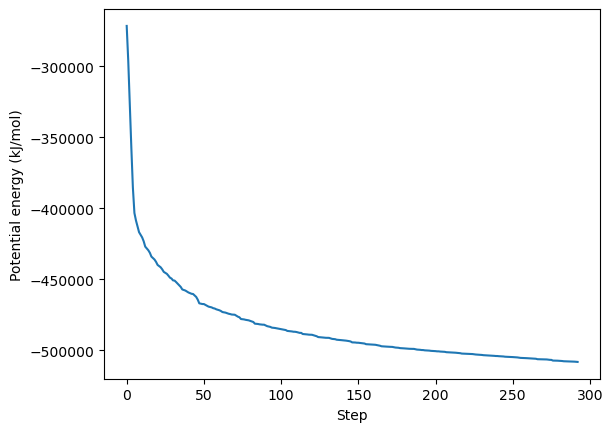

In [31]:
x,y = np.loadtxt("potential.xvg",comments=("@",'#'),unpack=True)
plt.plot(x,y)
plt.xlabel("Step")
plt.ylabel("Potential energy (kJ/mol)")
plt.show()